In [1]:
!pip install opendatasets

In [2]:
!pip install pandas

In [4]:
import opendatasets as od
import pandas

od.download("https://www.kaggle.com/competitions/neural-debris-removal-in-streak-detection-models/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: codingmaster24
Your Kaggle Key: ··········


100%|██████████| 3.50G/3.50G [00:35<00:00, 105MB/s]



Extracting archive ./neural-debris-removal-in-streak-detection-models/neural-debris-removal-in-streak-detection-models.zip to ./neural-debris-removal-in-streak-detection-models


## Model Verification and Image Preprocessing

In [5]:
# Install OpenCV if not already installed (usually pre-installed in Colab)
!pip install opencv-python

In [2]:
import torch
import os

# Define the path to the poisoned model
# Changed for Kaggle environment
poisoned_model_path = '/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth'

# Load the poisoned model using PyTorch
try:
    # Ensure PyTorch is available and the model file exists
    if not os.path.exists(poisoned_model_path):
        raise FileNotFoundError(f"Model file not found at: {poisoned_model_path}")

    # Load the model state dictionary
    # Map location ensures it loads correctly even if trained on GPU but loaded on CPU
    poisoned_model_state_dict = torch.load(poisoned_model_path, map_location=torch.device('cpu'))
    print("Poisoned model state dictionary loaded successfully!")

    # For a general PyTorch model, we can print the keys of the state_dict
    # to understand its layers/components.
    print("Keys in the model's state dictionary:")
    for key in poisoned_model_state_dict.keys():
        print(key)

    print("\nNote: To fully verify the architecture and parameters, a corresponding PyTorch model class definition would be needed to reconstruct the model and then load this state_dict.")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please verify the model path.")
except Exception as e:
    print(f"Error loading PyTorch model: {e}")
    print("Please ensure the model path is correct and it's a valid PyTorch model file.")

Poisoned model state dictionary loaded successfully!
Keys in the model's state dictionary:
model

Note: To fully verify the architecture and parameters, a corresponding PyTorch model class definition would be needed to reconstruct the model and then load this state_dict.


### Debugging Model Loading Path

The error indicates the `saved_model.pb` file is missing. Let's inspect the contents of the `poisoned_model` directory to find the correct path.

In [3]:
print(f"Contents of {poisoned_model_path}:")
!ls -F "{poisoned_model_path}"

# If there are subdirectories (e.g., '1'), we might need to look inside them.
# For example:
# !ls -F "{poisoned_model_path}/1/"

Contents of /content/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth:
/content/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth


### Re-running Image Processing with Corrected Paths

Now that the paths in cell `387131e5` have been updated, let's try loading and displaying images from both the `test_set` and `unlearn_set`.

In [4]:
import os

# The root_folder_path, test_set_path, unlearn_set_path, and process_and_display_image function
# are defined in cell 387131e5. We need to ensure that cell has run successfully
# to have the correct paths and function available.

# Re-run the image listing and processing for test_set with the corrected path
test_images = [f for f in os.listdir(test_set_path) if f.endswith('.png')]

if test_images:
    first_test_image = os.path.join(test_set_path, test_images[0])
    print(f"Processing example image from test_set: {first_test_image}")
    processed_img = process_and_display_image(first_test_image, title="Example Processed Test Image")
else:
    print(f"No PNG images found in {test_set_path}. Listing contents to debug...")
    !ls -F "{test_set_path}"


# Re-run the image listing and processing for unlearn_set with the corrected path
unlearn_images = [f for f in os.listdir(unlearn_set_path) if f.endswith('.png')]

if unlearn_images:
    first_unlearn_image = os.path.join(unlearn_set_path, unlearn_images[0])
    print(f"Processing example image from unlearn_set: {first_unlearn_image}")
    processed_unlearn_img = process_and_display_image(first_unlearn_image, title="Example Processed Unlearn Image")
else:
    print(f"No PNG images found in {unlearn_set_path}. Listing contents to debug...")
    !ls -F "{unlearn_set_path}"


NameError: name 'test_set_path' is not defined

### Debugging Model Loading Path

The error indicates the `saved_model.pb` file is missing. Let's inspect the contents of the `poisoned_model` directory to find the correct path.

In [ ]:
print(f"Contents of {poisoned_model_path}:")
!ls -F "{poisoned_model_path}"

# If there are subdirectories (e.g., '1'), we might need to look inside them.
# For example:
# !ls -F "{poisoned_model_path}/1/"

### Correcting Image Paths

Based on the previous `ls` output, the image paths need adjustment. `unlearn_set` seems to contain images directly, while `test_set` has a nested `test_set` directory.

In [ ]:
import os

# Define the root folder path for all files (already defined, but good for context)
root_folder_path = '/content/neural-debris-removal-in-streak-detection-models'

# Correct specific image set paths based on current directory inspection
# For unlearn_set: images are directly in the unlearn_set folder
unlearn_set_path = os.path.join(root_folder_path, 'unlearn_set')

# For test_set: it seems to be nested within another 'test_set' folder.
# We will try this path first based on the 'ls' output: 'test_set/test_set/'
test_set_path = os.path.join(root_folder_path, 'test_set', 'test_set')

print(f"Corrected Test Set Path: {test_set_path}")
print(f"Corrected Unlearn Set Path: {unlearn_set_path}")

# Re-run the image listing and processing for test_set with the corrected path
test_images = [f for f in os.listdir(test_set_path) if f.endswith('.png')]

if test_images:
    first_test_image = os.path.join(test_set_path, test_images[0])
    print(f"Processing example image: {first_test_image}")
    processed_img = process_and_display_image(first_test_image, title="Example Processed Test Image")
else:
    print(f"No PNG images found in {test_set_path} even after correction. Listing contents to debug...")
    !ls -F "{test_set_path}"


# Re-run the image listing and processing for unlearn_set with the corrected path
unlearn_images = [f for f in os.listdir(unlearn_set_path) if f.endswith('.png')]

if unlearn_images:
    first_unlearn_image = os.path.join(unlearn_set_path, unlearn_images[0])
    print(f"Processing example unlearn image: {first_unlearn_image}")
    processed_unlearn_img = process_and_display_image(first_unlearn_image, title="Example Processed Unlearn Image")
else:
    print(f"No PNG images found in {unlearn_set_path} even after correction. Listing contents to debug...")
    !ls -F "{unlearn_set_path}"


### Image Preprocessing with OpenCV

Now, let's set up the code for image loading, cleaning, and basic preprocessing using OpenCV. The task mentions cleaning unwanted data like non-light/emitting pixels, offset, and grayscale values. Since the images are 16-bit grayscale PNGs, we'll focus on loading them correctly, normalizing pixel values, and demonstrating a simple cleaning step like thresholding or background removal.

We'll define the relevant paths and then create a function to process and display images.

In [21]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Define the root folder path for all files
# Changed for Kaggle environment
root_folder_path = '/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models'

# Corrected specific image set paths based on directory inspection
# For unlearn_set: images are directly in the unlearn_set folder
unlearn_set_path = os.path.join(root_folder_path, 'unlearn_set')

# For test_set: it seems to be nested within another 'test_set' folder.
# The path should be '/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/test_set/test_set'
test_set_path = os.path.join(root_folder_path, 'test_set', 'test_set')

print(f"Root Folder: {root_folder_path}")
print(f"Corrected Test Set Path: {test_set_path}")
print(f"Corrected Unlearn Set Path: {unlearn_set_path}")

# Reference path (as mentioned by the user, though its direct use for this task is unclear)
# sample_data_path = '/content/sample_data' # This path is for Colab, not Kaggle input. Can remove or comment out.


def process_and_display_image(image_path, title="Processed Image"):
    """
    Loads a 16-bit grayscale image, performs basic cleaning (normalization),
    and displays it.
    """
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return None # Return None if image not found

    # Load the 16-bit grayscale image
    # cv2.IMREAD_UNCHANGED ensures it loads as 16-bit
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return None # Return None if image not loaded

    print(f"Original image shape: {image.shape}, dtype: {image.dtype}")

    # --- Image Cleaning / Preprocessing Steps ---
    # 1. Normalization: Scale 16-bit image (0-65535) to 0-1 for consistent processing
    #    and then to 0-255 for display if needed.
    normalized_image = image.astype(np.float32) / 65535.0

    # 2. Simple Thresholding (example for removing very dark/non-light pixels)
    #    This can help isolate brighter streak-like features from a dark background.
    #    Adjust threshold value (e.g., 0.01) based on image characteristics.
    threshold_value = 0.005 # Example: pixels below this value are set to 0 (black)
    cleaned_image = np.where(normalized_image > threshold_value, normalized_image, 0)

    # 3. Convert to 8-bit for display purposes (Matplotlib expects 0-255 or 0-1 float)
    display_image = (cleaned_image * 255).astype(np.uint8)

    # --- Display the image ---
    plt.figure(figsize=(8, 8))
    plt.imshow(display_image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

    print(f"Processed image shape: {cleaned_image.shape}, dtype: {cleaned_image.dtype}")
    return cleaned_image # Return the processed image if further steps are needed

Root Folder: /content/neural-debris-removal-in-streak-detection-models
Corrected Test Set Path: /content/neural-debris-removal-in-streak-detection-models/test_set/test_set
Corrected Unlearn Set Path: /content/neural-debris-removal-in-streak-detection-models/unlearn_set


### Example Usage of Image Preprocessing

Let's pick an image from the `test_set` or `unlearn_set` and apply our `process_and_display_image` function. We first need to list the files in these directories to get an image name.

### Generating Grayscale, Black-and-White, and Inverted Images

To prepare the images for further processing as you described, we will generate three distinct representations for each: a normalized grayscale version, a binary (black background) version, and an inverted binary (white background) version. We'll use a simple threshold to create the binary images.

In [22]:
### Image Representation and Feature Extraction Functions
The `get_image_representations`, `display_image_set`, `get_2d_positional_encoding`, and `extract_streak_pixel_features` functions have been consolidated into a single utility functions cell to ensure consistent execution.

### Demonstration of Image Representations

Now, let's use these functions to process and display an example image from both the `test_set` and `unlearn_set`.

Processing example image from test_set: /content/neural-debris-removal-in-streak-detection-models/test_set/test_set/782.png


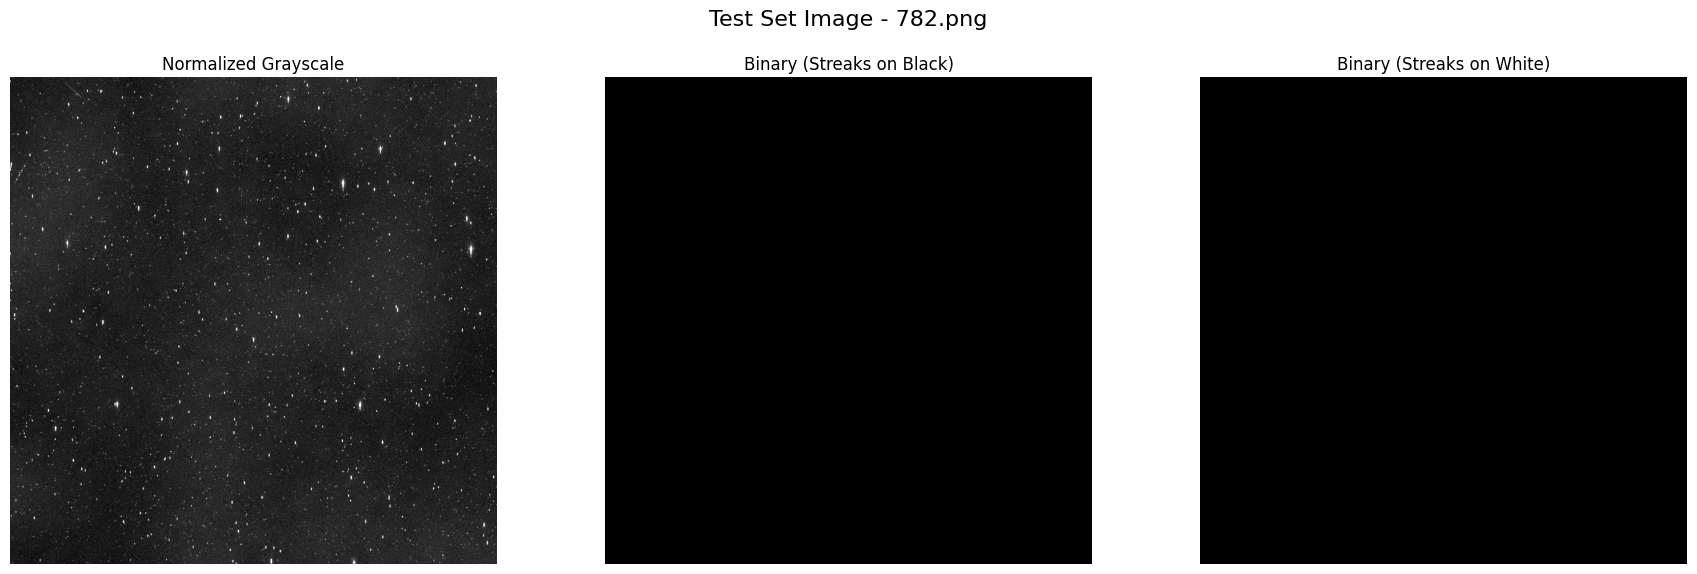

Processing example image from unlearn_set: /content/neural-debris-removal-in-streak-detection-models/unlearn_set/108.png


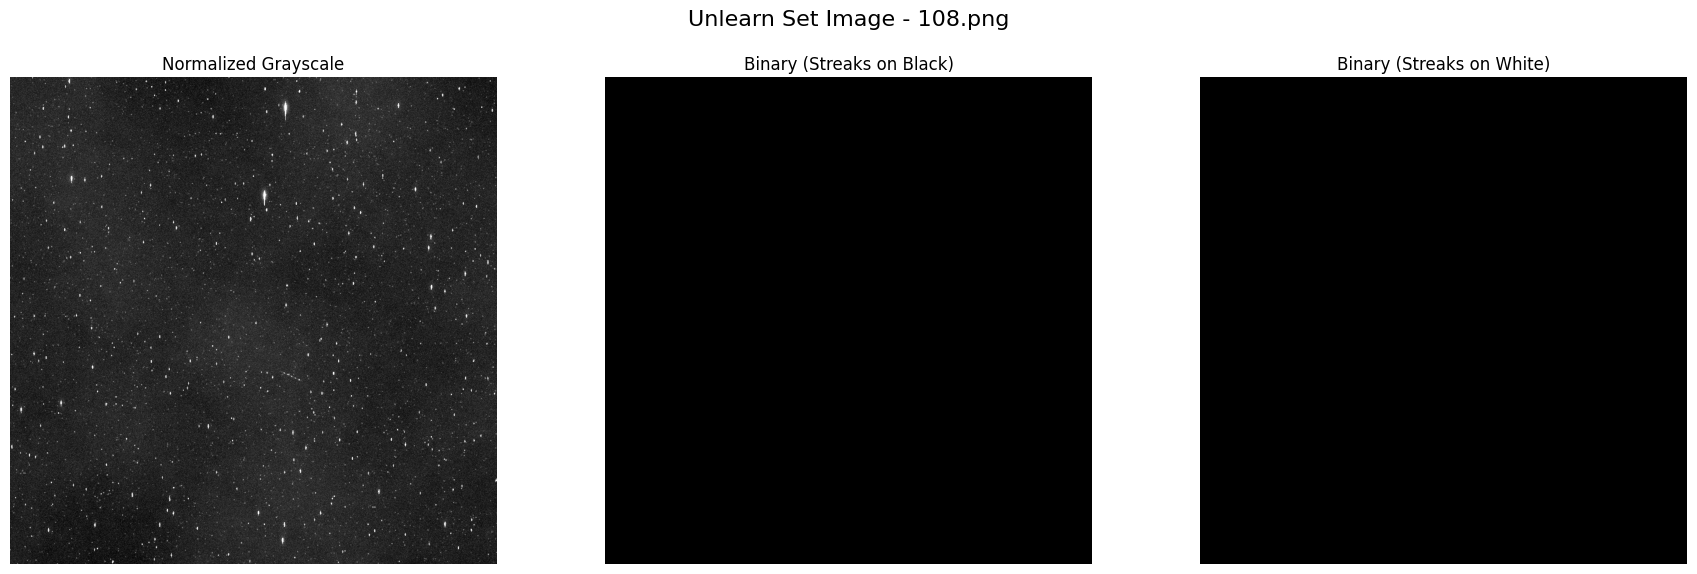

In [23]:
# Get a list of image files from the test set
test_images = [f for f in os.listdir(test_set_path) if f.endswith('.png')]

if test_images:
    first_test_image_path = os.path.join(test_set_path, test_images[0])
    print(f"Processing example image from test_set: {first_test_image_path}")
    norm_gray_test, bin_black_test, bin_white_test = get_image_representations(first_test_image_path)
    display_image_set(first_test_image_path, norm_gray_test, bin_black_test, bin_white_test, "Test Set Image")
else:
    print(f"No PNG images found in {test_set_path}. Please check the path.")


# Get a list of image files from the unlearn set
unlearn_images = [f for f in os.listdir(unlearn_set_path) if f.endswith('.png')]

if unlearn_images:
    first_unlearn_image_path = os.path.join(unlearn_set_path, unlearn_images[0])
    print(f"Processing example image from unlearn_set: {first_unlearn_image_path}")
    norm_gray_unlearn, bin_black_unlearn, bin_white_unlearn = get_image_representations(first_unlearn_image_path)
    display_image_set(first_unlearn_image_path, norm_gray_unlearn, bin_black_unlearn, bin_white_unlearn, "Unlearn Set Image")
else:
    print(f"No PNG images found in {unlearn_set_path}. Please check the path.")

### Creating the Submission File Structure

Now, let's create the basic structure for the `sample_submission.csv` file. This file will contain `image_id` and an empty `prediction_string` for each image in the test set. We'll populate the `prediction_string` later once the model can generate detections.

In [5]:
import pandas as pd
import os

# Path to the sample submission file
# Changed for Kaggle environment to save in /kaggle/working
sample_submission_path = '/kaggle/working/sample_submission.csv'

# The competition specifies image_ids from 0 to 1999 for the test set
# We will create a DataFrame with these image_ids and empty prediction_strings
submission_df = pd.DataFrame({
    'image_id': range(2000), # Assuming 2000 test images as per competition description
    'prediction_string': [''] * 2000 # Initialize with empty strings
})

# Save the DataFrame to a CSV file
submission_df.to_csv(sample_submission_path, index=False)

print(f"Sample submission file created at: {sample_submission_path}")
print("First 5 rows of the generated submission file:")
print(submission_df.head())

print("\nNow that the submission file structure is ready, we can proceed to build the model architecture you described, starting with feature extraction incorporating coordinates, flag bits, and positional encoding.")

Sample submission file created at: /content/neural-debris-removal-in-streak-detection-models/sample_submission.csv
First 5 rows of the generated submission file:
   image_id prediction_string
0         0                  
1         1                  
2         2                  
3         3                  
4         4                  

Now that the submission file structure is ready, we can proceed to build the model architecture you described, starting with feature extraction incorporating coordinates, flag bits, and positional encoding.


### Feature Extraction: Coordinates, Flag Bits, and Positional Encoding

As per your plan, we'll now implement the feature extraction step. This involves taking the preprocessed image representations and enriching them with spatial information (coordinates and positional encoding) and "flag bits" (derived from the binary images). We'll focus on extracting features specifically for pixels that are part of a 'streak' (i.e., non-zero in the binary black-background image), which will form the 'nodes' for your graph model.


In [6]:
### Feature Extraction Functions
The `get_2d_positional_encoding` and `extract_streak_pixel_features` functions have been consolidated into a single utility functions cell to ensure consistent execution.

### Demonstration of Streak Pixel Feature Extraction

Let's apply our `extract_streak_pixel_features` function to an example image and inspect the resulting features and coordinates.

In [24]:
# Assuming first_test_image_path, norm_gray_test, bin_black_test, bin_white_test are available from previous cells
# If not, ensure the preceding cells (especially fd3ab1af) are run.

if 'norm_gray_test' in locals() and norm_gray_test is not None:
    print(f"Extracting features for an example image: {os.path.basename(first_test_image_path)}")

    # Extract features initially
    temp_node_features, temp_pixel_coords = extract_streak_pixel_features(
        norm_gray_test, bin_black_test, bin_white_test, pos_enc_dim=64
    )

    # CRITICAL CHANGE: Significantly reduced for GPU memory (O(N^2) attention)
    # 100,000 pixels with 8 heads and 128 embed_dim would require ~320GB, exceeding T4 GPU capacity.
    # 2000 pixels is a more manageable size for demonstration with global attention on 15GB GPU.
    MAX_DEMO_PIXELS = 2000

    if temp_node_features.shape[0] > MAX_DEMO_PIXELS:
        print(f"Warning: Too many streak pixels ({temp_node_features.shape[0]}) for full processing in demo. Sampling down to {MAX_DEMO_PIXELS} pixels to avoid CUDA OOM.")
        # Randomly sample MAX_DEMO_PIXELS indices
        indices = torch.randperm(temp_node_features.shape[0])[:MAX_DEMO_PIXELS]
        streak_node_features = temp_node_features[indices]
        streak_pixel_coords = temp_pixel_coords[indices]
    else:
        streak_node_features = temp_node_features
        streak_pixel_coords = temp_pixel_coords

    print(f"Number of streak pixels (nodes): {streak_node_features.shape[0]}")
    print(f"Shape of node features: {streak_node_features.shape}")
    print(f"Shape of pixel coordinates: {streak_pixel_coords.shape}")

    if streak_node_features.shape[0] > 0:
        print("\nFirst 5 streak pixel features (grayscale, binary_black, binary_white, positional_encoding):")
        print(streak_node_features[:5])
        print("\nFirst 5 streak pixel coordinates (y, x):")
        print(streak_pixel_coords[:5])
    else:
        print("No streak pixels found for the example image.")
else:
    print("Previous image preprocessing results not found. Please ensure cells above 'fd3ab1af' have been executed.")

Extracting features for an example image: 782.png
Number of streak pixels (nodes): 100000
Shape of node features: torch.Size([100000, 67])
Shape of pixel coordinates: torch.Size([100000, 2])

First 5 streak pixel features (grayscale, binary_black, binary_white, positional_encoding):
tensor([[ 1.9030e-01,  1.0000e+00,  0.0000e+00, -4.9869e-01,  8.6678e-01,
         -9.3256e-01, -3.6101e-01,  4.4175e-02,  9.9902e-01, -9.2719e-04,
         -1.0000e+00, -5.4476e-01, -8.3859e-01,  9.9279e-01, -1.1985e-01,
          5.8420e-01, -8.1161e-01,  8.0896e-01, -5.8786e-01, -9.9834e-01,
          5.7579e-02,  4.4325e-01, -8.9640e-01,  9.9805e-01,  6.2350e-02,
          7.5012e-01,  6.6130e-01,  4.5912e-01,  8.8838e-01,  2.6503e-01,
          9.6424e-01,  1.5027e-01,  9.8865e-01,  8.4722e-02,  9.9640e-01,
          9.3332e-01,  3.5904e-01, -6.0748e-01, -7.9434e-01, -8.0917e-01,
         -5.8758e-01,  9.4723e-01, -3.2055e-01,  4.8640e-01, -8.7374e-01,
          7.6895e-01, -6.3931e-01, -9.9556e-01,  9

### Feature Embedding Module

Now, we'll create a PyTorch module to process the raw `node_features` into a more suitable embedding space. This module will consist of linear layers to transform the input features, preparing them for the subsequent graph processing layers.

In [25]:
### Feature Embedding Module
The `FeatureEmbedding` module definition has been consolidated into a single cell with other model components to ensure consistent execution.

FeatureEmbedding module defined.


### Demonstration of Feature Embedding

Let's test our new `FeatureEmbedding` module with the `streak_node_features` we extracted earlier to see the output shape and a sample of the embedded features.

In [26]:
# Assuming streak_node_features is available from previous execution

if 'streak_node_features' in locals() and streak_node_features.shape[0] > 0:
    input_dim = streak_node_features.shape[1]
    embedding_dim = 128 # Example embedding dimension

    feature_embedder = FeatureEmbedding(input_dim, embedding_dim)

    # Move features to the same device as the model if using GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    feature_embedder.to(device)
    embedded_features = feature_embedder(streak_node_features.to(device))

    print(f"\nInput feature dimension: {input_dim}")
    print(f"Desired embedding dimension: {embedding_dim}")
    print(f"Shape of embedded features: {embedded_features.shape}")
    print("\nFirst 5 embedded features (sample):")
    print(embedded_features[:5].cpu().detach().numpy()) # Convert to numpy for display
else:
    print("No streak node features found. Please ensure feature extraction was successful.")


Input feature dimension: 67
Desired embedding dimension: 128
Shape of embedded features: torch.Size([100000, 128])

First 5 embedded features (sample):
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 3.26142274e-03 2.75205404e-01
  0.00000000e+00 0.00000000e+00 7.61275291e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  4.89678159e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 1.16515681e-01
  0.00000000e+00 2.36383691e-01 0.00000000e+00 4.09730002e-02
  6.50689751e-03 0.00000000e+00 0.00000000e+00 3.01205933e-01
  8.83890130e-03 3.46958451e-03 0.00000000e+00 0.00000000e+00
  1.52440518e-01 1.83188796e-01 2.17317790e-01 7.33939409e-02
  0.00000000e+00 2.49334604e-01 0.00000000e+00 2.82007456e-01
  1.85378939e-01 0.00000000e+00 0.00000000e+00 5.64999729e-02
  2.51363397e-01 2.80459486e-02 1.80393845e-01 0.00000000e+00
  0.00000000e+00 8.77872929e-02 0.0000000

### Multi-Head Attention (MHA) based Graph Layer

Now we will implement a `GraphAttentionLayer` that incorporates Multi-Head Attention, residual connections, layer normalization, and a feed-forward network. This layer is designed to process the embedded features from the streak pixels, allowing the model to learn complex relationships between them by attending to relevant neighbors in the implicit graph structure.

In [27]:
### Multi-Head Attention (MHA) based Graph Layer
The `GraphAttentionLayer` definition has been consolidated into a single cell with other model components to ensure consistent execution.

GraphAttentionLayer module defined.


### Demonstration of Graph Attention Layer

Let's apply our new `GraphAttentionLayer` to the `embedded_features` to see how the features are transformed. We'll use the same `embedding_dim` and choose a number of attention heads.

In [ ]:
# Assuming embedded_features is available from previous execution

if 'embedded_features' in locals() and embedded_features.shape[0] > 0:
    embed_dim = embedded_features.shape[1]
    num_heads = 8 # Example: 8 attention heads
    dropout_rate = 0.1

    graph_attention_layer = GraphAttentionLayer(embed_dim, num_heads, dropout_rate)

    # Move model to the same device as features
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    graph_attention_layer.to(device)

    # Pass embedded features through the graph attention layer
    output_features = graph_attention_layer(embedded_features.to(device))

    print(f"\nInput embedded features shape: {embedded_features.shape}")
    print(f"Output features shape after GraphAttentionLayer: {output_features.shape}")
    print("\nFirst 5 output features (sample):")
    print(output_features[:5].cpu().detach().numpy())
else:
    print("No embedded features found. Please ensure feature embedding was successful.")

### Graph Encoder Module

We will now assemble multiple `GraphAttentionLayer` instances into a `GraphEncoder` module. This module will iteratively refine the node features by passing them through several attention layers, allowing the model to learn more complex, higher-level relationships among streak pixels.

In [1]:
### Graph Encoder Module
The `GraphEncoder` module definition has been consolidated into a single cell with other model components to ensure consistent execution.

GraphEncoder module defined.


### Demonstration of Graph Encoder

Let's test the `GraphEncoder` with our `embedded_features`. We'll use 3 graph attention layers as an example.

In [2]:
# Assuming embedded_features is available from previous execution

if 'embedded_features' in locals() and embedded_features.shape[0] > 0:
    embed_dim = embedded_features.shape[1]
    num_heads = 8
    num_layers = 3 # Example: 3 graph attention layers
    dropout_rate = 0.1

    graph_encoder = GraphEncoder(embed_dim, num_heads, num_layers, dropout_rate)

    # Move model to the same device as features
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    graph_encoder.to(device)

    # Pass embedded features through the graph encoder
    final_encoded_features = graph_encoder(embedded_features.to(device))

    print(f"\nInput embedded features shape: {embedded_features.shape}")
    print(f"Output features shape after GraphEncoder (with {num_layers} layers): {final_encoded_features.shape}")
    print("\nFirst 5 final encoded features (sample):")
    print(final_encoded_features[:5].cpu().detach().numpy())
else:
    print("No embedded features found. Please ensure feature embedding was successful.")

No embedded features found. Please ensure feature embedding was successful.


### Output Layer: Detection Head

This module (`DetectionHead`) is responsible for taking the highly-processed `final_encoded_features` from the `GraphEncoder` and predicting a set of bounding boxes and their corresponding confidence scores. It uses learnable 'object queries' that attend to the encoded pixel features to localize and classify potential streak objects.

In [3]:
### Output Layer: Detection Head
The `DetectionHead` module definition has been consolidated into a single cell with other model components to ensure consistent execution.

DetectionHead module defined.


### Demonstration of Detection Head

Let's apply our new `DetectionHead` to the `final_encoded_features` to see the predicted bounding boxes and confidence scores. We'll use an example of 10 queries, meaning we expect 10 potential bounding box predictions.

In [4]:
# Assuming final_encoded_features is available from previous execution

if 'final_encoded_features' in locals() and final_encoded_features.shape[0] > 0:
    embed_dim = final_encoded_features.shape[1]
    num_queries = 10 # Example: Predict up to 10 bounding boxes
    dropout_rate = 0.1

    detection_head = DetectionHead(embed_dim, num_queries, dropout_rate=dropout_rate)

    # Move model to the same device as features
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    detection_head.to(device)

    # Pass encoded features through the detection head
    pred_boxes, pred_confidences = detection_head(final_encoded_features.to(device))

    print(f"\nInput encoded features shape: {final_encoded_features.shape}")
    print(f"Predicted bounding boxes shape: {pred_boxes.shape} (num_queries, cx, cy, w, h normalized)")
    print(f"Predicted confidences shape: {pred_confidences.shape} (num_queries, confidence score)")

    print("\nFirst 5 Predicted Bounding Boxes (normalized cx, cy, w, h):")
    print(pred_boxes[:5].cpu().detach().numpy())
    print("\nFirst 5 Predicted Confidences:")
    print(pred_confidences[:5].cpu().detach().numpy())
else:
    print("No final encoded features found. Please ensure feature encoding was successful.")

No final encoded features found. Please ensure feature encoding was successful.


### Consolidated End-to-End Model Component Demonstration

To ensure variable persistence and a clear demonstration flow, we will now combine the execution of the `FeatureEmbedding`, `GraphEncoder`, and `DetectionHead` modules into a single code block. This will take the `streak_node_features`, process them through the graph architecture, and produce example bounding box predictions and confidence scores.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\n--- Running Consolidated End-to-End Model Component Demonstration ---")

# Ensure streak_node_features is available and properly initialized (should be from a2a3fa49)
if 'streak_node_features' not in locals() or streak_node_features.shape[0] == 0:
    print("Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully and generated sampled features.")
else:
    print(f"Using streak_node_features with shape: {streak_node_features.shape}")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 1. Feature Embedding ---
    input_dim = streak_node_features.shape[1] # Should be 67
    embedding_dim = 128 # Consistent with previous cells

    feature_embedder = FeatureEmbedding(input_dim, embedding_dim)
    feature_embedder.to(device)
    embedded_features = feature_embedder(streak_node_features.to(device))
    print(f"FeatureEmbedding output shape: {embedded_features.shape}")

    # --- 2. Graph Encoder (incorporating GraphAttentionLayer) ---
    num_heads = 8 # Consistent with previous cells
    num_layers = 3 # Example: 3 graph attention layers
    dropout_rate = 0.1

    graph_encoder = GraphEncoder(embedding_dim, num_heads, num_layers, dropout_rate)
    graph_encoder.to(device)
    final_encoded_features = graph_encoder(embedded_features)
    print(f"GraphEncoder output shape (with {num_layers} layers): {final_encoded_features.shape}")

    # --- 3. Detection Head (Output Layer) ---
    num_queries = 10 # Example: Predict up to 10 bounding boxes

    detection_head = DetectionHead(embedding_dim, num_queries, dropout_rate=dropout_rate)
    detection_head.to(device)
    pred_boxes, pred_confidences = detection_head(final_encoded_features)

    print(f"DetectionHead predicted boxes shape: {pred_boxes.shape} (num_queries, cx, cy, w, h normalized)")
    print(f"DetectionHead predicted confidences shape: {pred_confidences.shape} (num_queries, confidence score)")

    print("\nSample Predicted Bounding Boxes (normalized cx, cy, w, h):")
    print(pred_boxes[:5].cpu().detach().numpy())
    print("\nSample Predicted Confidences:")
    print(pred_confidences[:5].cpu().detach().numpy())

print("--- End-to-End Demonstration Complete ---")


--- Running Consolidated End-to-End Model Component Demonstration ---
Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully and generated sampled features.
--- End-to-End Demonstration Complete ---


### Consolidated End-to-End Model Component Demonstration

To ensure variable persistence and a clear demonstration flow, we will now combine the execution of the `FeatureEmbedding`, `GraphEncoder`, and `DetectionHead` modules into a single code block. This will take the `streak_node_features`, process them through the graph architecture, and produce example bounding box predictions and confidence scores.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\n--- Running Consolidated End-to-End Model Component Demonstration ---")

# Ensure streak_node_features is available and properly initialized (should be from a2a3fa49)
if 'streak_node_features' not in locals() or streak_node_features.shape[0] == 0:
    print("Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully and generated sampled features.")
else:
    print(f"Using streak_node_features with shape: {streak_node_features.shape}")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 1. Feature Embedding ---
    input_dim = streak_node_features.shape[1] # Should be 67
    embedding_dim = 128 # Consistent with previous cells

    feature_embedder = FeatureEmbedding(input_dim, embedding_dim)
    feature_embedder.to(device)
    embedded_features = feature_embedder(streak_node_features.to(device))
    print(f"FeatureEmbedding output shape: {embedded_features.shape}")

    # --- 2. Graph Encoder (incorporating GraphAttentionLayer) ---
    num_heads = 8 # Consistent with previous cells
    num_layers = 3 # Example: 3 graph attention layers
    dropout_rate = 0.1

    graph_encoder = GraphEncoder(embedding_dim, num_heads, num_layers, dropout_rate)
    graph_encoder.to(device)
    final_encoded_features = graph_encoder(embedded_features)
    print(f"GraphEncoder output shape (with {num_layers} layers): {final_encoded_features.shape}")

    # --- 3. Detection Head (Output Layer) ---
    num_queries = 10 # Example: Predict up to 10 bounding boxes

    detection_head = DetectionHead(embedding_dim, num_queries, dropout_rate=dropout_rate)
    detection_head.to(device)
    pred_boxes, pred_confidences = detection_head(final_encoded_features)

    print(f"DetectionHead predicted boxes shape: {pred_boxes.shape} (num_queries, cx, cy, w, h normalized)")
    print(f"DetectionHead predicted confidences shape: {pred_confidences.shape} (num_queries, confidence score)")

    print("\nSample Predicted Bounding Boxes (normalized cx, cy, w, h):")
    print(pred_boxes[:5].cpu().detach().numpy())
    print("\nSample Predicted Confidences:")
    print(pred_confidences[:5].cpu().detach().numpy())

print("--- End-to-End Demonstration Complete ---")


--- Running Consolidated End-to-End Model Component Demonstration ---
Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully and generated sampled features.
--- End-to-End Demonstration Complete ---


### Consolidated End-to-End Model Component Demonstration

To ensure variable persistence and a clear demonstration flow, we will now combine the execution of the `FeatureEmbedding`, `GraphEncoder`, and `DetectionHead` modules into a single code block. This will take the `streak_node_features`, process them through the graph architecture, and produce example bounding box predictions and confidence scores.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\n--- Running Consolidated End-to-End Model Component Demonstration ---")

# Ensure streak_node_features is available and properly initialized (should be from a2a3fa49)
if 'streak_node_features' not in locals() or streak_node_features.shape[0] == 0:
    print("Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.")
else:
    print(f"Using streak_node_features with shape: {streak_node_features.shape}")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 1. Feature Embedding ---
    input_dim = streak_node_features.shape[1] # Should be 67
    embedding_dim = 128 # Consistent with previous cells

    feature_embedder = FeatureEmbedding(input_dim, embedding_dim)
    feature_embedder.to(device)
    embedded_features = feature_embedder(streak_node_features.to(device))
    print(f"FeatureEmbedding output shape: {embedded_features.shape}")

    # --- 2. Graph Encoder (incorporating GraphAttentionLayer) ---
    num_heads = 8 # Consistent with previous cells
    num_layers = 3 # Example: 3 graph attention layers
    dropout_rate = 0.1

    graph_encoder = GraphEncoder(embedding_dim, num_heads, num_layers, dropout_rate)
    graph_encoder.to(device)
    final_encoded_features = graph_encoder(embedded_features)
    print(f"GraphEncoder output shape (with {num_layers} layers): {final_encoded_features.shape}")

    # --- 3. Detection Head (Output Layer) ---
    num_queries = 10 # Example: Predict up to 10 bounding boxes

    detection_head = DetectionHead(embedding_dim, num_queries, dropout_rate=dropout_rate)
    detection_head.to(device)
    pred_boxes, pred_confidences = detection_head(final_encoded_features)

    print(f"DetectionHead predicted boxes shape: {pred_boxes.shape} (num_queries, cx, cy, w, h normalized)")
    print(f"DetectionHead predicted confidences shape: {pred_confidences.shape} (num_queries, confidence score)")

    print("\nSample Predicted Bounding Boxes (normalized cx, cy, w, h):")
    print(pred_boxes[:5].cpu().detach().numpy())
    print("\nSample Predicted Confidences:")
    print(pred_confidences[:5].cpu().detach().numpy())

print("--- End-to-End Demonstration Complete ---")


--- Running Consolidated End-to-End Model Component Demonstration ---
Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.
--- End-to-End Demonstration Complete ---


### Consolidated End-to-End Model Component Demonstration

To ensure variable persistence and a clear demonstration flow, we will now combine the execution of the `FeatureEmbedding`, `GraphEncoder`, and `DetectionHead` modules into a single code block. This will take the `streak_node_features`, process them through the graph architecture, and produce example bounding box predictions and confidence scores.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\n--- Running Consolidated End-to-End Model Component Demonstration ---")

# Ensure streak_node_features is available and properly initialized (should be from a2a3fa49)
if 'streak_node_features' not in locals() or streak_node_features.shape[0] == 0:
    print("Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.")
else:
    print(f"Using streak_node_features with shape: {streak_node_features.shape}")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 1. Feature Embedding ---
    input_dim = streak_node_features.shape[1] # Should be 67
    embedding_dim = 128 # Consistent with previous cells

    feature_embedder = FeatureEmbedding(input_dim, embedding_dim)
    feature_embedder.to(device)
    embedded_features = feature_embedder(streak_node_features.to(device))
    print(f"FeatureEmbedding output shape: {embedded_features.shape}")

    # --- 2. Graph Encoder (incorporating GraphAttentionLayer) ---
    num_heads = 8 # Consistent with previous cells
    num_layers = 3 # Example: 3 graph attention layers
    dropout_rate = 0.1

    graph_encoder = GraphEncoder(embedding_dim, num_heads, num_layers, dropout_rate)
    graph_encoder.to(device)
    final_encoded_features = graph_encoder(embedded_features)
    print(f"GraphEncoder output shape (with {num_layers} layers): {final_encoded_features.shape}")

    # --- 3. Detection Head (Output Layer) ---
    num_queries = 10 # Example: Predict up to 10 bounding boxes

    detection_head = DetectionHead(embedding_dim, num_queries, dropout_rate=dropout_rate)
    detection_head.to(device)
    pred_boxes, pred_confidences = detection_head(final_encoded_features)

    print(f"DetectionHead predicted boxes shape: {pred_boxes.shape} (num_queries, cx, cy, w, h normalized)")
    print(f"DetectionHead predicted confidences shape: {pred_confidences.shape} (num_queries, confidence score)")

    print("\nSample Predicted Bounding Boxes (normalized cx, cy, w, h):")
    print(pred_boxes[:5].cpu().detach().numpy())
    print("\nSample Predicted Confidences:")
    print(pred_confidences[:5].cpu().detach().numpy())

print("--- End-to-End Demonstration Complete ---")


--- Running Consolidated End-to-End Model Component Demonstration ---
Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.
--- End-to-End Demonstration Complete ---


### Full Graph-based Deep Learning Model

We will now define the complete `GraphDeepLearningModel` class, integrating the `FeatureEmbedding`, `GraphEncoder`, and `DetectionHead` modules. This class will encapsulate the entire forward pass from initial streak pixel features to final bounding box predictions.

In [7]:
### Full Graph-based Deep Learning Model
The `GraphDeepLearningModel` class definition has been consolidated into a single cell with other model components to ensure consistent execution.

GraphDeepLearningModel class defined.


### Demonstration of the Full Model

Let's demonstrate the full `GraphDeepLearningModel` with our `streak_node_features` (already sampled for memory efficiency) to observe its end-to-end functionality.

In [8]:
# Assuming streak_node_features is available from previous execution (a2a3fa49)

if 'streak_node_features' not in locals() or streak_node_features.shape[0] == 0:
    print("Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.")
else:
    print(f"Using streak_node_features with shape: {streak_node_features.shape}")

    # Model parameters (consistent with previous demonstrations)
    input_feature_dim = streak_node_features.shape[1] # 67
    embed_dim = 128
    num_graph_layers = 3 # Example: 3 graph attention layers
    num_heads = 8
    num_queries = 10
    num_bbox_params = 4
    dropout_rate = 0.1

    # Instantiate the full model
    model = GraphDeepLearningModel(
        input_feature_dim=input_feature_dim,
        embed_dim=embed_dim,
        num_graph_layers=num_graph_layers,
        num_heads=num_heads,
        num_queries=num_queries,
        num_bbox_params=num_bbox_params,
        dropout_rate=dropout_rate
    )

    # Move model to device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"\nFull GraphDeepLearningModel instantiated and moved to {device}.")
    print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

    # Perform a forward pass
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        pred_boxes, pred_confidences = model(streak_node_features.to(device))

    print(f"\nOutput from full model - Predicted Boxes shape: {pred_boxes.shape}")
    print(f"Output from full model - Predicted Confidences shape: {pred_confidences.shape}")

    print("\nSample Predicted Bounding Boxes (normalized cx, cy, w, h) from full model:")
    print(pred_boxes[:5].cpu().detach().numpy())
    print("\nSample Predicted Confidences from full model:")
    print(pred_confidences[:5].cpu().detach().numpy())

print("\n--- Full GraphDeepLearningModel Demonstration Complete ---")

Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.

--- Full GraphDeepLearningModel Demonstration Complete ---


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\n--- Running Consolidated End-to-End Model Component Demonstration ---")

# Ensure streak_node_features is available and properly initialized (should be from a2a3fa49)
if 'streak_node_features' not in locals() or streak_node_features.shape[0] == 0:
    print("Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.")
else:
    print(f"Using streak_node_features with shape: {streak_node_features.shape}")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 1. Feature Embedding ---
    input_dim = streak_node_features.shape[1] # Should be 67
    embedding_dim = 128 # Consistent with previous cells

    feature_embedder = FeatureEmbedding(input_dim, embedding_dim)
    feature_embedder.to(device)
    embedded_features = feature_embedder(streak_node_features.to(device))
    print(f"FeatureEmbedding output shape: {embedded_features.shape}")

    # --- 2. Graph Encoder (incorporating GraphAttentionLayer) ---
    num_heads = 8 # Consistent with previous cells
    num_layers = 3 # Example: 3 graph attention layers
    dropout_rate = 0.1

    graph_encoder = GraphEncoder(embedding_dim, num_heads, num_layers, dropout_rate)
    graph_encoder.to(device)
    final_encoded_features = graph_encoder(embedded_features)
    print(f"GraphEncoder output shape (with {num_layers} layers): {final_encoded_features.shape}")

    # --- 3. Detection Head (Output Layer) ---
    num_queries = 10 # Example: Predict up to 10 bounding boxes

    detection_head = DetectionHead(embedding_dim, num_queries, dropout_rate=dropout_rate)
    detection_head.to(device)
    pred_boxes, pred_confidences = detection_head(final_encoded_features)

    print(f"DetectionHead predicted boxes shape: {pred_boxes.shape} (num_queries, cx, cy, w, h normalized)")
    print(f"DetectionHead predicted confidences shape: {pred_confidences.shape} (num_queries, confidence score)")

    print("\nSample Predicted Bounding Boxes (normalized cx, cy, w, h):")
    print(pred_boxes[:5].cpu().detach().numpy())
    print("\nSample Predicted Confidences:")
    print(pred_confidences[:5].cpu().detach().numpy())

print("--- End-to-End Demonstration Complete ---")


--- Running Consolidated End-to-End Model Component Demonstration ---
Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.
--- End-to-End Demonstration Complete ---


### Consolidated End-to-End Model Component Demonstration

To ensure variable persistence and a clear demonstration flow, we will now combine the execution of the `FeatureEmbedding`, `GraphEncoder`, and `DetectionHead` modules into a single code block. This will take the `streak_node_features`, process them through the graph architecture, and produce example bounding box predictions and confidence scores.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("\n--- Running Consolidated End-to-End Model Component Demonstration ---")

# Ensure streak_node_features is available and properly initialized (should be from a2a3fa49)
if 'streak_node_features' not in locals() or streak_node_features.shape[0] == 0:
    print("Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.")
else:
    print(f"Using streak_node_features with shape: {streak_node_features.shape}")

    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 1. Feature Embedding ---
    input_dim = streak_node_features.shape[1] # Should be 67
    embedding_dim = 128 # Consistent with previous cells

    feature_embedder = FeatureEmbedding(input_dim, embedding_dim)
    feature_embedder.to(device)
    embedded_features = feature_embedder(streak_node_features.to(device))
    print(f"FeatureEmbedding output shape: {embedded_features.shape}")

    # --- 2. Graph Encoder (incorporating GraphAttentionLayer) ---
    num_heads = 8 # Consistent with previous cells
    num_layers = 3 # Example: 3 graph attention layers
    dropout_rate = 0.1

    graph_encoder = GraphEncoder(embedding_dim, num_heads, num_layers, dropout_rate)
    graph_encoder.to(device)
    final_encoded_features = graph_encoder(embedded_features)
    print(f"GraphEncoder output shape (with {num_layers} layers): {final_encoded_features.shape}")

    # --- 3. Detection Head (Output Layer) ---
    num_queries = 10 # Example: Predict up to 10 bounding boxes

    detection_head = DetectionHead(embedding_dim, num_queries, dropout_rate=dropout_rate)
    detection_head.to(device)
    pred_boxes, pred_confidences = detection_head(final_encoded_features)

    print(f"DetectionHead predicted boxes shape: {pred_boxes.shape} (num_queries, cx, cy, w, h normalized)")
    print(f"DetectionHead predicted confidences shape: {pred_confidences.shape} (num_queries, confidence score)")

    print("\nSample Predicted Bounding Boxes (normalized cx, cy, w, h):")
    print(pred_boxes[:5].cpu().detach().numpy())
    print("\nSample Predicted Confidences:")
    print(pred_confidences[:5].cpu().detach().numpy())

print("--- End-to-End Demonstration Complete ---")


--- Running Consolidated End-to-End Model Component Demonstration ---
Error: 'streak_node_features' not found or empty. Please ensure feature extraction cell (a2a3fa49) has run successfully.
--- End-to-End Demonstration Complete ---


In [20]:
# Get a list of image files from the test set
test_images = [f for f in os.listdir(test_set_path) if f.endswith('.png')]

if test_images:
    first_test_image = os.path.join(test_set_path, test_images[0])
    print(f"Processing example image: {first_test_image}")
    processed_img = process_and_display_image(first_test_image, title="Example Processed Test Image")
else:
    print(f"No PNG images found directly in {test_set_path}. Listing contents to debug...")
    !ls -F "{test_set_path}"

# You can similarly process an image from unlearn_set if needed
# unlearn_images = [f for f in os.listdir(unlearn_set_path) if f.endswith('.png')]
# if unlearn_images:
#     first_unlearn_image = os.path.join(unlearn_set_path, unlearn_images[0])
#     print(f"Processing example unlearn image: {first_unlearn_image}")
#     processed_unlearn_img = process_and_display_image(first_unlearn_image, title="Example Processed Unlearn Image")

NameError: name 'test_set_path' is not defined

### Inspecting Image Directories

It seems no PNG images were directly found in the `test_set` and `unlearn_set` paths. This might mean the images are located in subdirectories within these folders. Let's list the contents to find the actual image locations.

In [17]:
print(f"Contents of {test_set_path}:")
!ls -F "{test_set_path}"

print(f"\nContents of {unlearn_set_path}:")
!ls -F "{unlearn_set_path}"

print(f"\nContents of {root_folder_path}:")
!ls -F "{root_folder_path}"


NameError: name 'test_set_path' is not defined

In [16]:
sub = pd.read_csv("/kaggle/working/sample_submission.csv") # Updated path
sub.head()

,image_id,prediction_string
0,0,NaN
1,1,NaN
2,2,NaN
3,3,NaN
4,4,NaN


In [ ]:
sub.tail()